In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import plotly.express as px
# import plotly.graph_objects as go
import json
import copy
import os
from scipy import signal

In [4]:
fl = r"..\resources\mumeg_mks64.ced"
df = pd.read_csv(fl, sep='\t')
ch = df.loc[df.labels.isin(["C1", "Cz", "C2", "CP1", "CPz", "CP2"])].channum.values
ch

array([11, 17, 19, 43, 51, 52])

In [22]:
filename = r"../data/exports/check_processing_LL.h5"
with h5py.File(filename, "r") as h5f:
    print(h5f.keys())
    meta = h5f["eeg_processing_metadata/json"][()]
    raw_epochs = h5f["raw_epochs/data"][:]
    processed_epochs = h5f["processed_eeg_epochs/data"][:]
    tvec = h5f["processed_eeg_epochs/timestamps"][:]

<KeysViewHDF5 ['eeg_processing_metadata', 'emg_processing_metadata', 'epochs', 'processed_eeg_epochs', 'processed_emg_epochs', 'processed_mep_epochs', 'raw_epochs', 'timestamps']>


In [12]:
json.loads(meta)

{'kind': 'EEG',
 'settings': {'use_eeg': True,
  'do_averaging': True,
  'epoch_window_start_ms': -300,
  'epoch_window_end_ms': 600,
  'current_sampling_rate_Hz': 5000,
  'do_resampling': True,
  'resample_freq_Hz': 500,
  'do_highpass_filtering': False,
  'do_lowpass_filtering': True,
  'do_rereferencing': False,
  'do_CAR_filtering': True,
  'apply_ICA': True,
  'do_baseline_correction': True,
  'aver_methods': ['mean', 'median', 'trimmean'],
  'curr_aver_method': 'mean',
  'highpass_freq_Hz': 0.01,
  'lowpass_freq_Hz': 45,
  'rereference_channel': ['Fz'],
  'car_except_channels': ['TP9', 'FT9', 'FT10', 'TP10'],
  'baseline_methods': ['mean', 'median'],
  'curr_baseline_method': 'mean',
  'baseline_from_ms': -75,
  'baseline_to_ms': -20,
  'do_emg_highpass_filtering': False,
  'emg_highpass_freq_Hz': 10.0,
  'do_emg_lowpass_filtering': False,
  'emg_lowpass_freq_Hz': 1000,
  'do_emg_resampling': True,
  'emg_resample_freq_Hz': 2000,
  'do_emg_baseline_correction': True,
  'emg_basel

In [28]:
np.diff(tvec//1000000000)

array([2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2,
       2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2,
       2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2,
       1, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1,
       2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2,
       1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 2, 2])

In [6]:
raw_epochs.shape, processed_epochs.shape

((137, 72, 4500), (137, 64, 450))

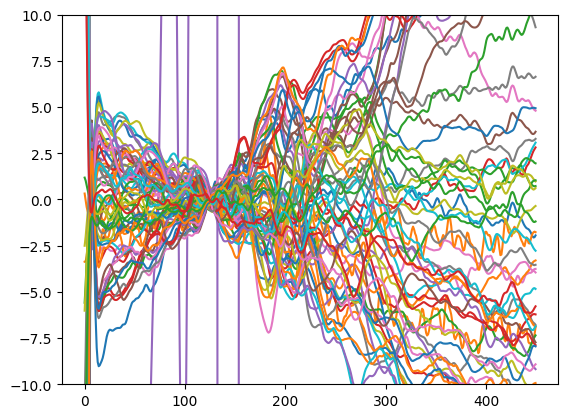

In [32]:
pr_ep = np.mean(processed_epochs, axis=0)
plt.plot(pr_ep.T);
plt.ylim(-10, 10);

In [19]:
np.std(pr_ep, axis=1)

array([ 17.886845 ,   3.0754845,   3.9828303,   8.529445 , 539.74207  ,
        16.19941  ,   2.4717307,   9.562793 ,  11.1749935,  12.624516 ,
        12.056718 ,   2.029736 ,  12.760191 ,   5.708013 ,  10.574656 ,
         8.954913 ,   3.6702034,   5.352946 ,  11.517369 ,   4.9463096,
         7.71081  ,   7.824151 ,   1.5091705,  13.319068 ,   7.7605104,
         4.2989545,   5.741091 ,   9.901096 ,   7.447187 ,   9.801347 ,
         1.6737716,   3.3391776,  11.696854 ,   5.47954  ,   6.4624805,
        13.596284 ,   7.7218833,   3.4186673,   1.1498942,   4.5057654,
         6.630545 ,   6.3873844,   2.4313178,   5.842783 ,  13.76815  ,
         5.9184303,  12.48335  ,   4.4890223,   2.3335934,   2.1991782,
         4.5643916,   6.056245 ,   0.9852748,  13.997097 ,  10.230071 ,
        11.607685 ,   6.943387 ,   3.6062076,   1.4455179,   4.523707 ,
        12.218302 ,  12.349266 ,   1.4750599,   2.4211652], dtype=float32)